In [1]:
!pip install tf_keras

In [2]:
import cv2 # biblioteca de visão computacional
import numpy as np
import time #funções de tempo e pausas
import pandas as pd
import matplotlib.pyplot as plt # criação de gráficos
from google.colab.patches import cv2_imshow
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import zipfile # manipulação de arquivos compactados
cv2.__version__ # mostra a versão do OpenCV

'5.0.0'

In [3]:
%tensorflow_version 2.x
import tensorflow # biblioteca para redes neurais
tensorflow.__version__ # mostra a versão do TensorFlow

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [4]:
from google.colab import drive
drive.mount('/content/gdrive') # conecta o google drive ao notebook
path = "/content/gdrive/My Drive/Material.zip" # define o caminho do arquivo zip
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall("./") # extrai todo o conteúdo da pasta atual
zip_object.close

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/My Drive/Material.zip' mode='r'>>

In [5]:
from tensorflow.keras.models import load_model # importa a função para carregar modelos
model = load_model("Material/modelo_02_expressoes.h5") # carrega o arquivo

In [6]:
arquivo_video = "Material/Videos/video_teste04.mp4"
cap = cv2.VideoCapture(arquivo_video) #abre o vídeo para processamento

conectado, video = cap.read()
print(conectado, video.shape) # mostra se o vídeo carregou e o tamanho da imagem

True (360, 640, 3)


In [7]:
redimensionar = True
largura_maxima = 600 #define o limite de largura para o vídeo

if (redimensionar and video.shape[1] > largura_maxima):
    proporcao = video.shape[1] / video.shape[0]
    video_largura = largura_maxima # define a nova largura fixa
    video_altura = int(video_largura / proporcao)
else:
    video_largura = video.shape[1]
    video_altura = video.shape[0]

In [8]:
# Nome do arquivo que será salvo
nome_arquivo = 'resultado_teste.avi'
fourcc = cv2.VideoWriter_fourcc(*'XVID')
fps = 24

saida_video = cv2.VideoWriter(nome_arquivo, fourcc, fps, (video_largura, video_altura))

In [9]:
!{sys.executable} -m pip uninstall opencv-python -y
!{sys.executable} -m pip uninstall opencv-contrib-python -y
!{sys.executable} -m pip install opencv-contrib-python

/bin/bash: line 1: {sys.executable}: command not found
/bin/bash: line 1: {sys.executable}: command not found
/bin/bash: line 1: {sys.executable}: command not found


30 frames processados...


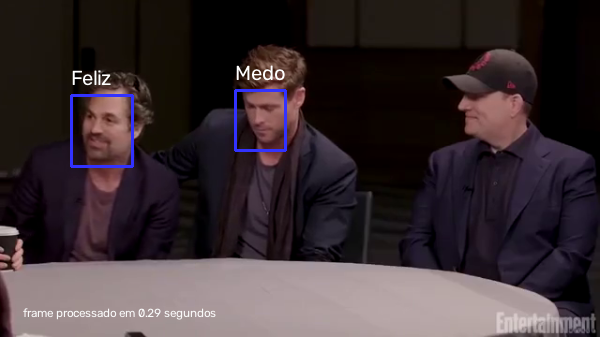

60 frames processados...


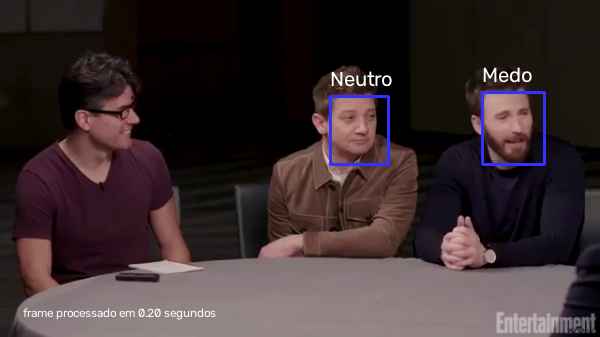

90 frames processados...


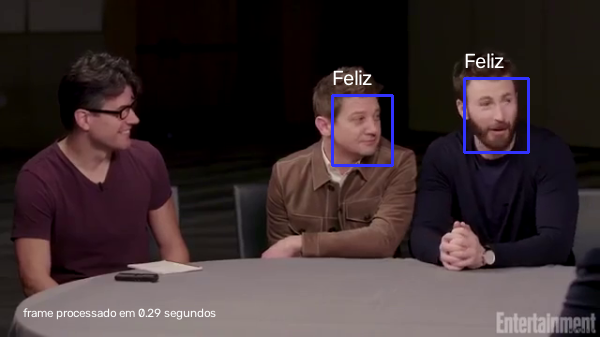

120 frames processados...


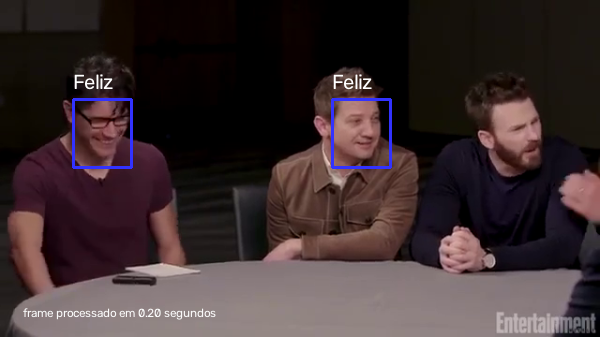

150 frames processados...


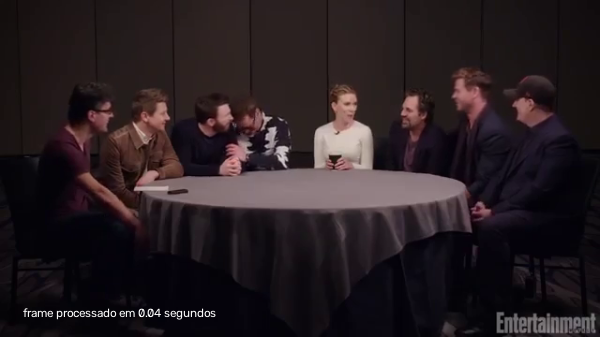

180 frames processados...


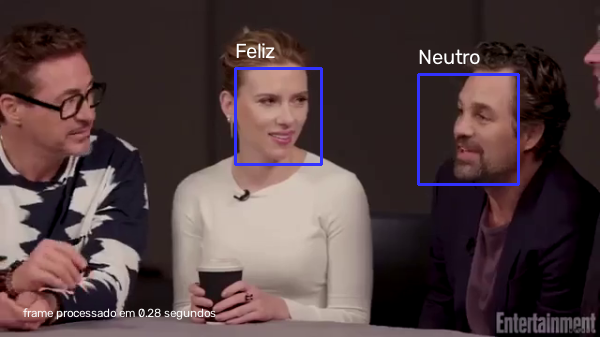

210 frames processados...


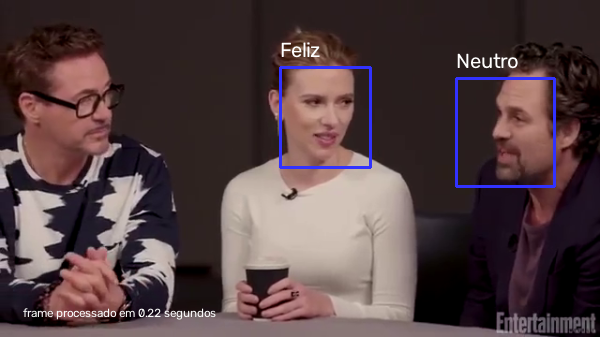

240 frames processados...


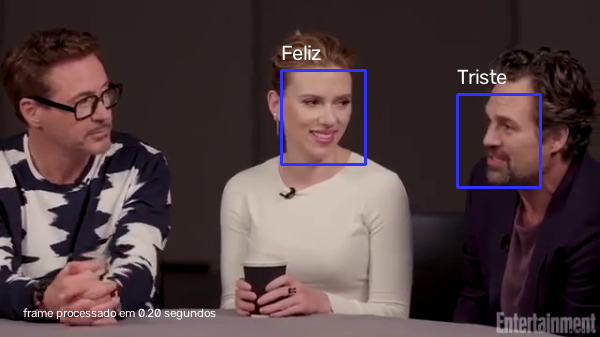

270 frames processados...


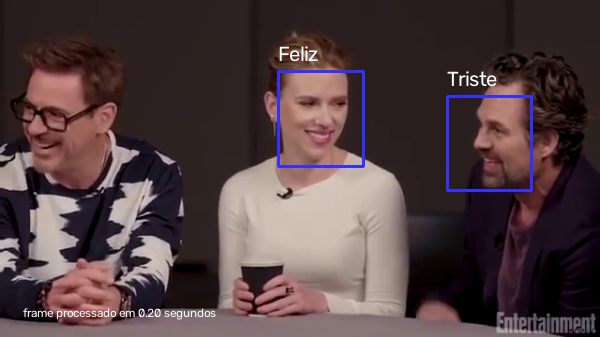

300 frames processados...


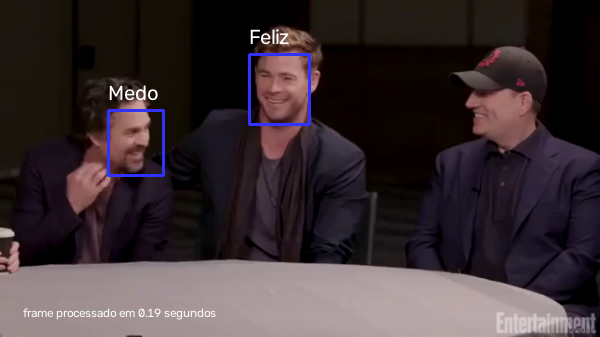

330 frames processados...


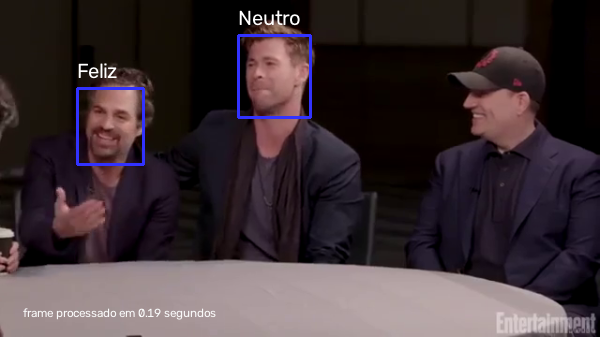

360 frames processados...


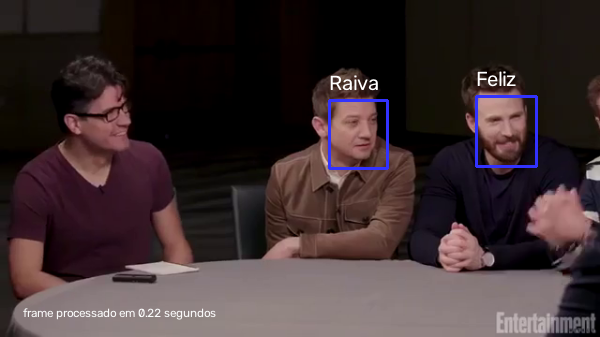

390 frames processados...


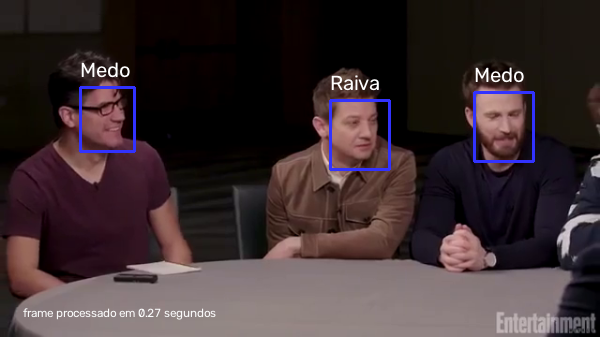

Concluido


In [10]:
import cv2
from tensorflow.keras.preprocessing.image import img_to_array

haarcascade_faces = '/content/Material/haarcascade_frontalface_default.xml'
fonte_pequena, fonte_media = 0.4, 0.7  # define tamanhos de fonte
fonte = cv2.FONT_HERSHEY_SIMPLEX  # define o tipo da fonte
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]  # lista de emoções

face_cascade = cv2.CascadeClassifier(haarcascade_faces)  # carrega uma vez só, fora do loop
if face_cascade.empty():
    raise RuntimeError('Não foi possível carregar o haarcascade.')

frame_count = 0
mostrar_a_cada = 30  # mostra 1 a cada 30 frames no notebook, pra não travar o Colab

while True:
    conectado, frame = cap.read()

    if not conectado:
        break

    t = time.time()

    if redimensionar:  # verifica se deve ajustar o tamanho
        frame = cv2.resize(frame, (video_largura, video_altura))  # redimensiona o quadro atual

    cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # converte a imagem para cinza
    faces = face_cascade.detectMultiScale(cinza, scaleFactor=1.2, minNeighbors=5, minSize=(30, 30))  # detecta rostos

    if len(faces) > 0:
        for (x, y, w, h) in faces:  # percorre cada rosto detectado
            frame = cv2.rectangle(frame, (x, y), (x + w, y + h + 10), (255, 50, 50), 2)  # desenha o retângulo
            roi = cinza[y:y + h, x:x + w]  # recorta apenas o rosto
            roi = cv2.resize(roi, (48, 48))
            roi = roi.astype("float") / 255.0
            roi = img_to_array(roi)
            roi = np.expand_dims(roi, axis=0)

            result = model.predict(roi, verbose=0)[0]

            if result is not None:
                resultado = np.argmax(result)
                cv2.putText(frame, expressoes[resultado], (x, y - 10), fonte, fonte_media,
                            (255, 255, 255), 1, cv2.LINE_AA)  # escreve a emoção no vídeo

    cv2.putText(frame, " frame processado em {:.2f} segundos".format(time.time() - t),
                (20, video_altura - 20), fonte, fonte_pequena, (250, 250, 250), 1, cv2.LINE_AA)

    saida_video.write(frame)  # salva o quadro no arquivo de saída

    frame_count += 1
    if frame_count % mostrar_a_cada == 0:
        print(f'{frame_count} frames processados...')
        cv2_imshow(frame)  # mostra só de vez em quando, pra acompanhar o progresso

print("Concluido")  # avisa que o processo finalizou
cap.release()  # fecha o arquivo de vídeo de entrada
saida_video.release()  # fecha o arquivo de vídeo salvo